# Solar Flare ML Prediction - Feature Importance Analysis

This notebook analyzes which McIntosh classification features are most important for predicting solar flares.

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

# Load data
names = ['mcint', 'mcint_evol', 'class']
df_train = pd.read_csv('../mcint_ml22.csv', names=names,
                        dtype={'mcint': str, 'mcint_evol': str, 'class': np.float64})

# Parse evolution codes
le = preprocessing.LabelEncoder()
df_train['mcint_enc'] = le.fit_transform(df_train['mcint'])
df_train['mcint_evol_enc'] = le.fit_transform(df_train['mcint_evol'])
df_train['z1'] = df_train['mcint_evol'].str[0]
df_train['p1'] = df_train['mcint_evol'].str[1]
df_train['c1'] = df_train['mcint_evol'].str[2]
df_train['z2'] = df_train['mcint_evol'].str[3]
df_train['p2'] = df_train['mcint_evol'].str[4]
df_train['c2'] = df_train['mcint_evol'].str[5]

X = df_train[['z1', 'p1', 'c1', 'z2', 'p2', 'c2']]
Y = df_train['class']

print(f"Data loaded: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Features: {X.columns.tolist()}")

Data loaded: 14251 samples, 6 features
Features: ['z1', 'p1', 'c1', 'z2', 'p2', 'c2']


## 2. Random Forest Feature Importance

Tree-based models provide built-in feature importance rankings based on how much each feature decreases impurity.

In [2]:
# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, Y)

# Get feature importances
feature_importance = rf_model.feature_importances_
features = X.columns.tolist()

# Sort by importance
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("\nRandom Forest Feature Importance:")
print(importance_df.to_string(index=False))
print(f"\nTotal importance sum: {importance_df['Importance'].sum():.4f}")


Random Forest Feature Importance:
Feature  Importance
     z2    0.283554
     c2    0.256030
     p2    0.180304
     p1    0.121291
     z1    0.102489
     c1    0.056333

Total importance sum: 1.0000


## 3. Feature Importance Visualization - Single Model

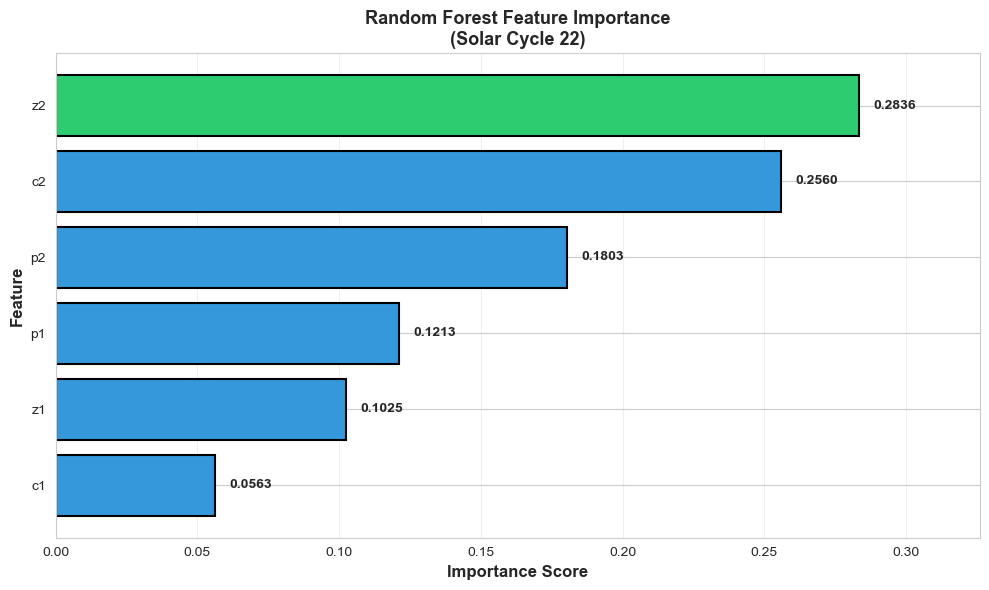

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(importance_df))]
bars = ax.barh(importance_df['Feature'], importance_df['Importance'], color=colors, edgecolor='black', linewidth=1.5)

ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature', fontsize=12, fontweight='bold')
ax.set_title('Random Forest Feature Importance\n(Solar Cycle 22)', fontsize=13, fontweight='bold')
ax.invert_yaxis()

# Add value labels
for i, (feature, importance) in enumerate(zip(importance_df['Feature'], importance_df['Importance'])):
    ax.text(importance + 0.005, i, f'{importance:.4f}', va='center', fontweight='bold')

ax.set_xlim(0, importance_df['Importance'].max() * 1.15)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 4. K-Fold Feature Importance Analysis

Analyze feature importance across multiple K-Fold splits to assess stability.

In [5]:
# K-Fold analysis for multiple algorithms
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Linear Discriminant': LinearDiscriminantAnalysis(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
feature_importances = {name: [] for name in models.keys()}

x_arr = X.values
y_arr = Y.values

for name, model in models.items():
    for train_idx, test_idx in cv.split(x_arr, y_arr):
        X_fold_train = x_arr[train_idx]
        y_fold_train = y_arr[train_idx]
        
        model.fit(X_fold_train, y_fold_train)
        
        # Extract feature importance
        if hasattr(model, 'feature_importances_'):
            feature_importances[name].append(model.feature_importances_)
        elif hasattr(model, 'coef_'):
            # For linear models, use absolute coefficient values
            feature_importances[name].append(np.abs(model.coef_[0]))

print("K-Fold Feature Importance Analysis (10 Folds)\n")
for model_name in models.keys():
    importances = np.array(feature_importances[model_name])
    print(f"{model_name}:")
    for i, feature in enumerate(features):
        mean_imp = importances[:, i].mean()
        std_imp = importances[:, i].std()
        print(f"  {feature}: {mean_imp:.4f} ± {std_imp:.4f}")
    print()

K-Fold Feature Importance Analysis (10 Folds)

Logistic Regression:
  z1: 0.0835 ± 0.0171
  p1: 0.0084 ± 0.0090
  c1: 0.0720 ± 0.0258
  z2: 0.4111 ± 0.0140
  p2: 0.2548 ± 0.0056
  c2: 0.9274 ± 0.0230

Linear Discriminant:
  z1: 0.1049 ± 0.0194
  p1: 0.0642 ± 0.0154
  c1: 0.3783 ± 0.0274
  z2: 0.1650 ± 0.0164
  p2: 0.3764 ± 0.0101
  c2: 1.0922 ± 0.0252

Decision Tree:
  z1: 0.0525 ± 0.0028
  p1: 0.0537 ± 0.0031
  c1: 0.0288 ± 0.0022
  z2: 0.4437 ± 0.1862
  p2: 0.1097 ± 0.0405
  c2: 0.3116 ± 0.2058

Random Forest:
  z1: 0.1035 ± 0.0094
  p1: 0.1141 ± 0.0083
  c1: 0.0646 ± 0.0057
  z2: 0.2911 ± 0.0064
  p2: 0.1807 ± 0.0035
  c2: 0.2460 ± 0.0086



## 5. Compare Feature Importance Across Models

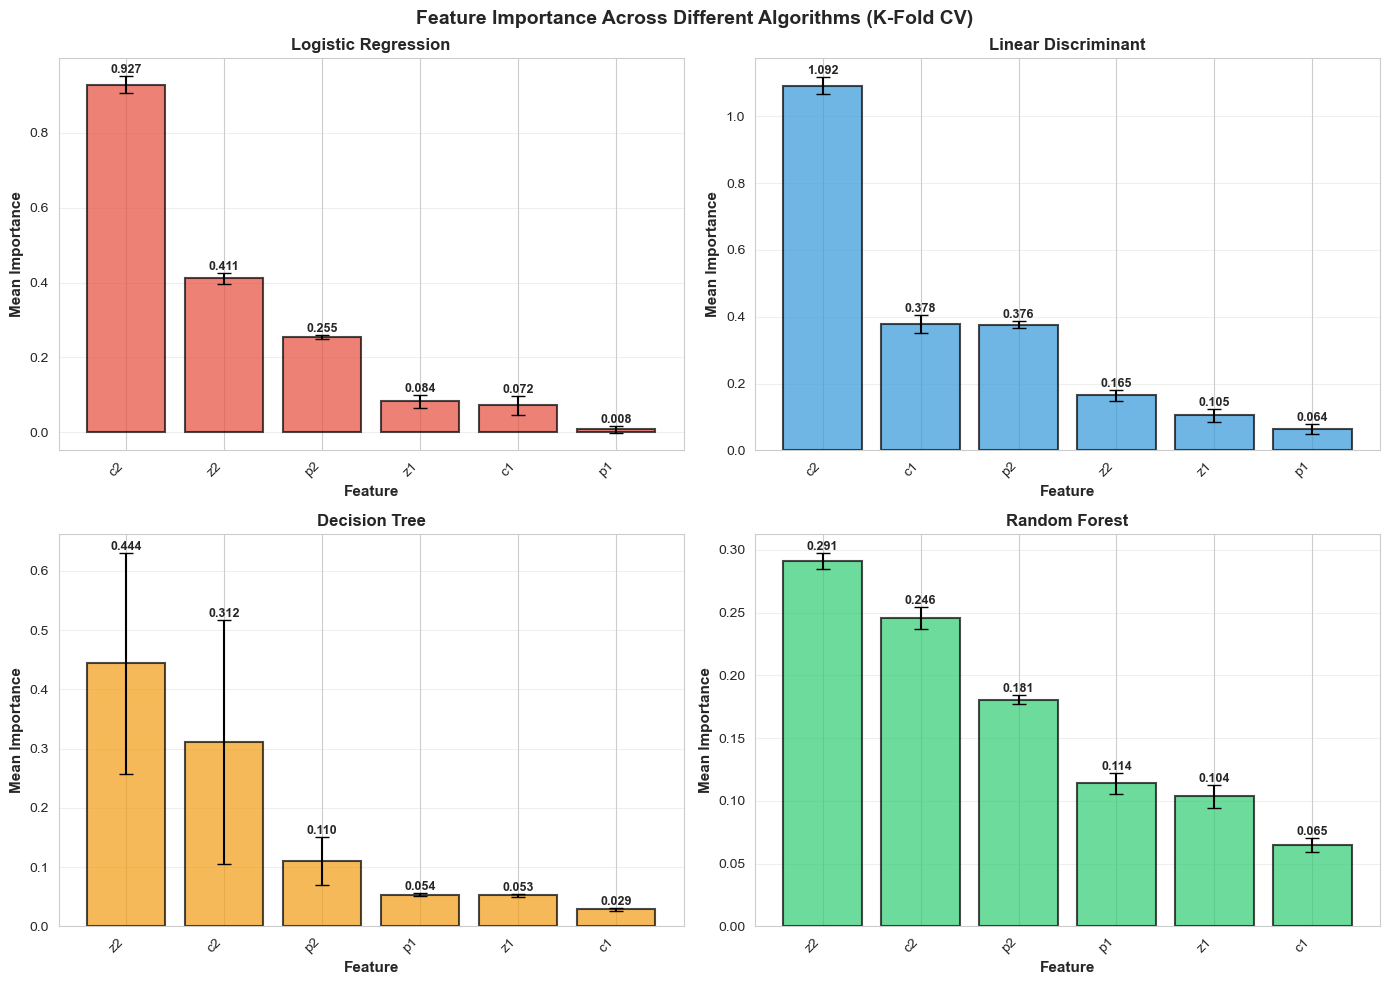

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Importance Across Different Algorithms (K-Fold CV)', fontsize=14, fontweight='bold')

colors_algo = ['#e74c3c', '#3498db', '#f39c12', '#2ecc71']

for ax, (model_name, color) in zip(axes.flat, zip(models.keys(), colors_algo)):
    importances = np.array(feature_importances[model_name])
    
    # Calculate statistics
    means = importances.mean(axis=0)
    stds = importances.std(axis=0)
    
    # Sort by mean importance
    sorted_idx = np.argsort(means)[::-1]
    sorted_features = [features[i] for i in sorted_idx]
    sorted_means = means[sorted_idx]
    sorted_stds = stds[sorted_idx]
    
    # Create bar plot with error bars
    x_pos = np.arange(len(sorted_features))
    bars = ax.bar(x_pos, sorted_means, yerr=sorted_stds, capsize=5,
                  color=color, alpha=0.7, edgecolor='black', linewidth=1.5)
    
    ax.set_ylabel('Mean Importance', fontsize=11, fontweight='bold')
    ax.set_xlabel('Feature', fontsize=11, fontweight='bold')
    ax.set_title(model_name, fontsize=12, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(sorted_features, rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar, mean, std in zip(bars, sorted_means, sorted_stds):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + std,
                f'{mean:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Normalized Feature Importance Comparison

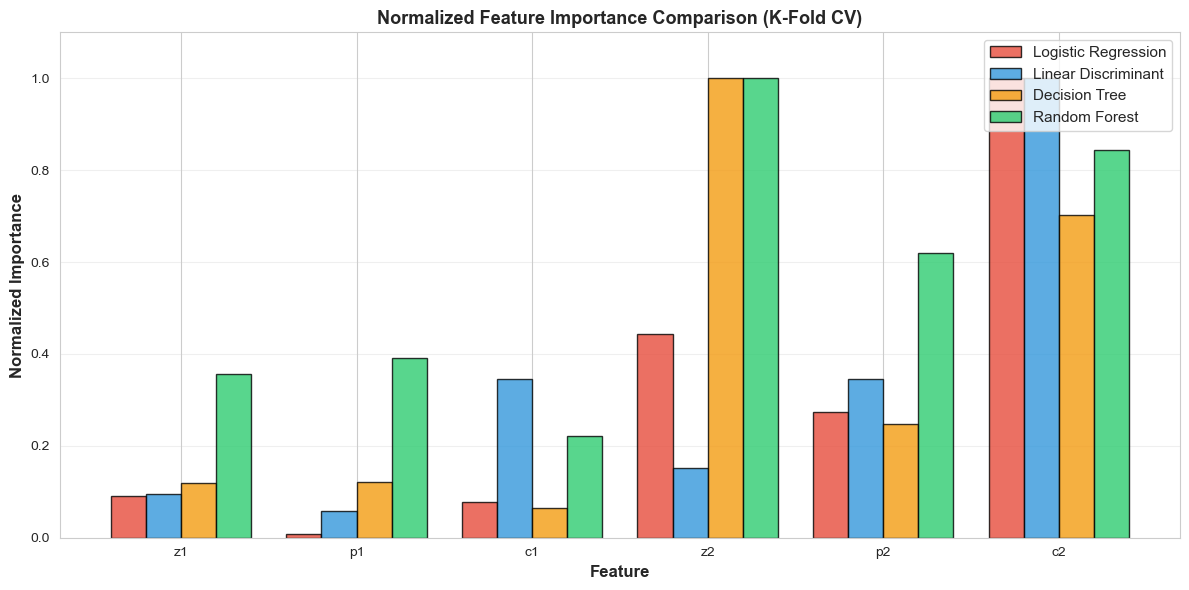

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

width = 0.2
x_pos = np.arange(len(features))

for i, (model_name, color) in enumerate(zip(models.keys(), colors_algo)):
    importances = np.array(feature_importances[model_name])
    means = importances.mean(axis=0)
    # Normalize to 0-1 range
    if means.max() > 0:
        means_normalized = means / means.max()
    else:
        means_normalized = means
    
    ax.bar(x_pos + i * width, means_normalized, width, label=model_name,
           color=color, alpha=0.8, edgecolor='black', linewidth=1)

ax.set_ylabel('Normalized Importance', fontsize=12, fontweight='bold')
ax.set_xlabel('Feature', fontsize=12, fontweight='bold')
ax.set_title('Normalized Feature Importance Comparison (K-Fold CV)', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos + width * 1.5)
ax.set_xticklabels(features)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

## 7. Feature Importance Boxplots (K-Fold Distribution)

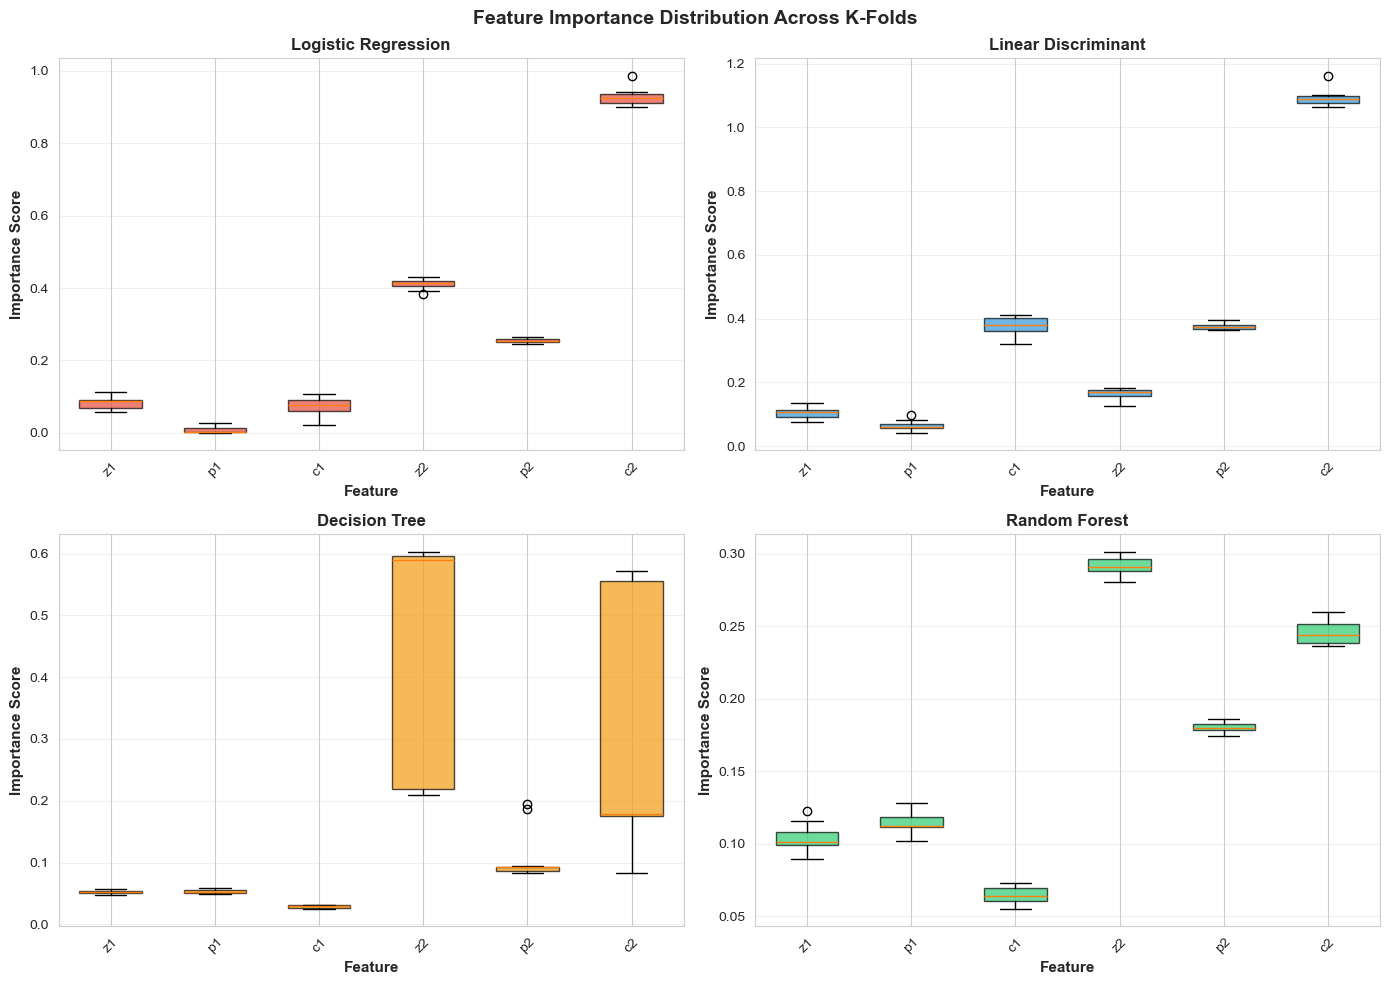

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Importance Distribution Across K-Folds', fontsize=14, fontweight='bold')

for ax, (model_name, color) in zip(axes.flat, zip(models.keys(), colors_algo)):
    importances = np.array(feature_importances[model_name])
    
    bp = ax.boxplot([importances[:, i] for i in range(len(features))],
                    labels=features, patch_artist=True, widths=0.6)
    
    # Color boxes
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_ylabel('Importance Score', fontsize=11, fontweight='bold')
    ax.set_xlabel('Feature', fontsize=11, fontweight='bold')
    ax.set_title(model_name, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 8. Summary and Interpretation

In [10]:
print("\n" + "="*80)
print("FEATURE IMPORTANCE ANALYSIS SUMMARY")
print("="*80)

print("\nFeature Definitions:")
print("  z1, p1, c1 = Starting Zurich, Penumbral, Compactness classes")
print("  z2, p2, c2 = Ending Zurich, Penumbral, Compactness classes")

print("\nRandom Forest Importance (Most reliable for tree-based models):")
for idx, row in importance_df.iterrows():
    percentage = (row['Importance'] / importance_df['Importance'].sum()) * 100
    print(f"  {idx+1}. {row['Feature']}: {row['Importance']:.4f} ({percentage:.1f}%)")

print("\nKey Insights:")
top_feature = importance_df.iloc[0]
print(f"  - Most important feature: {top_feature['Feature']} ({top_feature['Importance']:.4f})")
print(f"  - Accounts for {(top_feature['Importance']/importance_df['Importance'].sum())*100:.1f}% of total importance")

print("\nFeature Groups:")
start_features = importance_df[importance_df['Feature'].isin(['z1', 'p1', 'c1'])]['Importance'].sum()
end_features = importance_df[importance_df['Feature'].isin(['z2', 'p2', 'c2'])]['Importance'].sum()
print(f"  - Starting configuration (z1, p1, c1): {start_features:.4f} ({start_features*100:.1f}%)")
print(f"  - Ending configuration (z2, p2, c2): {end_features:.4f} ({end_features*100:.1f}%)")

print("\nPhysical Interpretation:")
print("  The evolution of sunspot classification (starting → ending) is key for flare prediction.")
print("  This reflects how magnetic field changes drive flare occurrence.")
print("="*80)


FEATURE IMPORTANCE ANALYSIS SUMMARY

Feature Definitions:
  z1, p1, c1 = Starting Zurich, Penumbral, Compactness classes
  z2, p2, c2 = Ending Zurich, Penumbral, Compactness classes

Random Forest Importance (Most reliable for tree-based models):
  4. z2: 0.2836 (28.4%)
  6. c2: 0.2560 (25.6%)
  5. p2: 0.1803 (18.0%)
  2. p1: 0.1213 (12.1%)
  1. z1: 0.1025 (10.2%)
  3. c1: 0.0563 (5.6%)

Key Insights:
  - Most important feature: z2 (0.2836)
  - Accounts for 28.4% of total importance

Feature Groups:
  - Starting configuration (z1, p1, c1): 0.2801 (28.0%)
  - Ending configuration (z2, p2, c2): 0.7199 (72.0%)

Physical Interpretation:
  The evolution of sunspot classification (starting → ending) is key for flare prediction.
  This reflects how magnetic field changes drive flare occurrence.
